# Моделирование: препроцессинг и проверка

**Train:** 672 пациента (80%)
**Test:** 168 пациентов (20%)
**Признаков:** 78
**Метрика:** Macro-F1 по `anemia_class`
**Stratified:** по `anemia_class`

In [1]:
# ============ ИМПОРТЫ ============
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    load_features, get_feature_columns, split_data,
    LEAKAGE_COLS, TARGET_MULTI, RANDOM_STATE
)

# Настройки
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("Импорты загружены")

Импорты загружены


In [2]:
# ============ ЗАГРУЗКА И SPLIT ============
df = load_features('../data/processed/df_features.csv')
print(f"Загружено: {df.shape}")

features = get_feature_columns(df)
print(f"Признаков: {len(features)}")

X_train, X_test, y_train, y_test, ids_train, ids_test = split_data(df)
print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Загружено: (840, 89)
Признаков: 78

Train: (672, 78)
Test:  (168, 78)


In [3]:
# ============ ПРОВЕРКА СТРАТИФИКАЦИИ ============
train_dist = y_train.value_counts(normalize=True).round(3)
test_dist = y_test.value_counts(normalize=True).round(3)

comparison = pd.DataFrame({
    'train': train_dist,
    'test': test_dist,
    'diff': (train_dist - test_dist).abs()
})

print(comparison)
print(f"\nMax diff: {comparison['diff'].max():.4f}")

                             train   test  diff
anemia_class                                   
B12_deficiency_anemia        0.077  0.077   0.0
B12_deficiency_no_anemia     0.060  0.060   0.0
B6_deficiency                0.042  0.042   0.0
anemia_other                 0.089  0.089   0.0
copper_deficiency            0.042  0.042   0.0
folate_deficiency_anemia     0.060  0.060   0.0
folate_deficiency_no_anemia  0.048  0.048   0.0
inflammation_anemia          0.077  0.077   0.0
iron_deficiency_anemia       0.137  0.137   0.0
latent_deficiency            0.101  0.101   0.0
mixed_deficiency             0.137  0.137   0.0
no_anemia_no_deficiency      0.131  0.131   0.0

Max diff: 0.0000


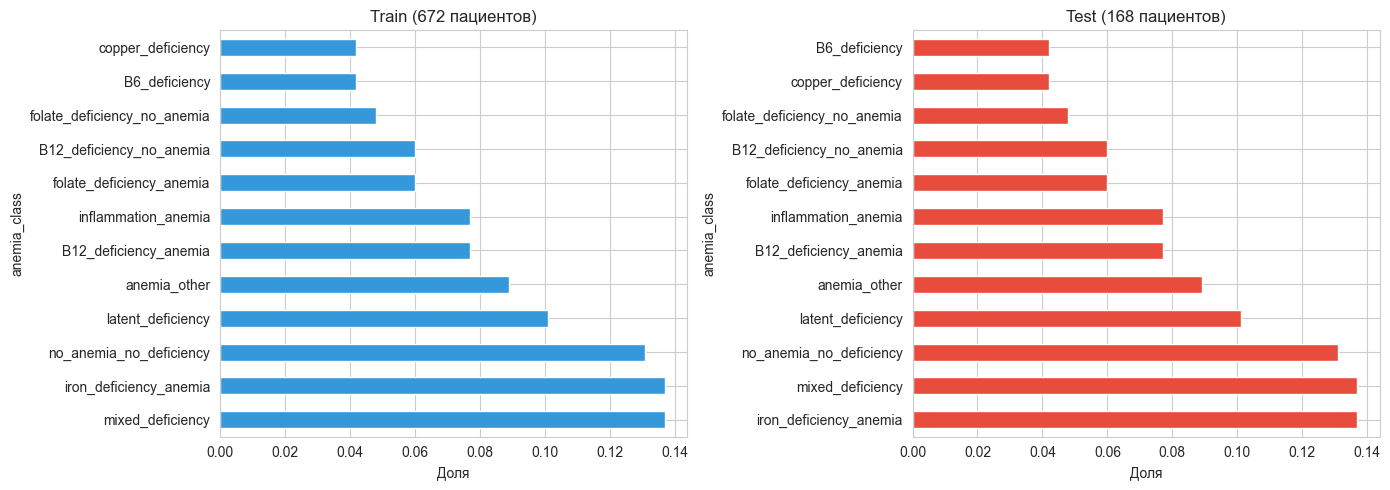

In [4]:
# ============ ВИЗУАЛИЗАЦИЯ ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_dist.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title(f'Train ({len(y_train)} пациентов)')
axes[0].set_xlabel('Доля')

test_dist.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title(f'Test ({len(y_test)} пациентов)')
axes[1].set_xlabel('Доля')

plt.tight_layout()
plt.show()

## Итоги препроцессинга

- **Train:** 672 пациента (80%)
- **Test:** 168 пациентов (20%)
- **Признаков:** 78 (без утечек)
- **Stratified:** по `anemia_class`
- **Max diff пропорций:** 0.0000 — идеальная стратификация
- **Утечки исключены:** `anemia`, `anemia_class`, `deficiency_cause`, 7 бинарных таргетов, `patient_id`

### Файлы
- `X_train.csv`, `X_test.csv` — признаки
- `y_train.csv`, `y_test.csv` — таргеты
- `train_ids.csv`, `test_ids.csv` — `patient_id`

### Следующий этап
- Обучение моделей 
- SHAP-интерпретация 

## Обучение моделей

**Train:** 672 × 78
**Test:** 168 × 78
**Классов:** 12
**Метрика:** Macro-F1

### План
1. Baseline (Dummy, LogisticRegression)
2. RandomForest
3. CatBoost
4. XGBoost / LightGBM
5. Сравнение и финальная модель

In [5]:
# ============ ИМПОРТЫ ДЛЯ МОДЕЛЕЙ ============
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Импорты для моделей загружены")

Импорты для моделей загружены


In [6]:
# ============ BASELINE 1: DummyClassifier ============
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("=== DummyClassifier (most_frequent) ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_dummy):.4f}")

=== DummyClassifier (most_frequent) ===
Accuracy:     0.1369
Macro-F1:     0.0201
Balanced acc: 0.0833


In [7]:
# ============ BASELINE 2: LogisticRegression ============
# LogisticRegression не работает с NaN — проверяем
print(f"NaN в X_train: {X_train.isna().sum().sum()}")
print(f"NaN в X_test:  {X_test.isna().sum().sum()}")

NaN в X_train: 9432
NaN в X_test:  2335


In [8]:
# ============ ИМПУТАЦИЯ ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ ============
from sklearn.impute import SimpleImputer

# Медиана по train (не по test!)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"X_train_imp: {X_train_imp.shape}, NaN: {X_train_imp.isna().sum().sum()}")
print(f"X_test_imp:  {X_test_imp.shape}, NaN: {X_test_imp.isna().sum().sum()}")

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'F'

In [9]:
# Какие типы данных в X_train?
print("Типы данных в X_train:")
print(X_train.dtypes.value_counts())
print("\nСтроковые колонки:")
print(X_train.select_dtypes(include='object').columns.tolist())

Типы данных в X_train:
int64      41
float64    35
object      2
Name: count, dtype: int64

Строковые колонки:
['sex', 'age_group']
